# 📊 LỚP 1.5: PHÂN TÍCH CHÉO (CROSS-TABULATION)
Giai đoạn này tập trung vào việc mô tả đặc tả hành vi của 4 Cụm Sản Phẩm (Clusters) qua các chiều không gian và thời gian.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)
print('✅ Các thư viện hiển thị Biểu đồ đã sẵn sàng')

✅ Các thư viện hiển thị Biểu đồ đã sẵn sàng


## Bước 1: Tiền Xử Lý (Gán nhãn tương quan Giá & Trọng Lượng)

In [7]:
file_path = '../data/orders_with_clusters.csv'
df = pd.read_csv(file_path)
df.columns = df.columns.str.upper()

# Nhãn đã được tối ưu rõ ràng thuộc tính Giá + Trọng lượng mà vẫn ngắn gọn cho đồ thị
label_map = {
    0: '2. Cao Cấp & Gọn Nhẹ (Quà Tặng)',
    1: '1. Giá Rẻ & Siêu Nhẹ (Lưu Niệm)',
    2: '3. Cao Cấp & Cồng Kềnh (Đồ Lớn)',
    3: '0. Giá Trung & Khối Lượng Vừa'
}

df['CLUSTER_NAME'] = df['CLUSTER'].map(label_map)
print(f'✅ Tải dữ liệu {len(df)} dòng thành công!')
df[['MADON', 'GIA', 'TRONGLUONG', 'CLUSTER_NAME']].head()

✅ Tải dữ liệu 47818 dòng thành công!


,MADON,GIA,TRONGLUONG,CLUSTER_NAME
0,10223,19.20,100,1. Giá Rẻ & Siêu Nhẹ (Lưu Niệm)
1,10224,110.90,800,0. Giá Trung & Khối Lượng Vừa
2,10225,29.89,300,1. Giá Rẻ & Siêu Nhẹ (Lưu Niệm)
3,10226,58.99,1550,0. Giá Trung & Khối Lượng Vừa
4,10227,169.99,3950,3. Cao Cấp & Cồng Kềnh (Đồ Lớn)


## BƯỚC 2: PHÂN TÍCH VỚI DIMENSION THỜI GIAN (QUÝ)
Tạo Bản đồ nhiệt Heatmap

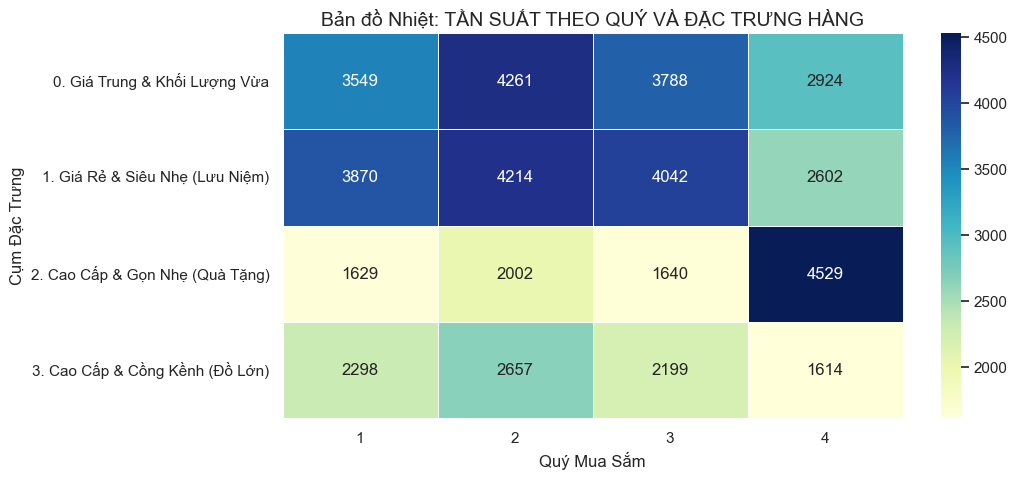

In [8]:
cross_quy = pd.crosstab(df['CLUSTER_NAME'], df['QUY'])

plt.figure(figsize=(10, 5))
sns.heatmap(cross_quy, annot=True, fmt="d", cmap="YlGnBu", linewidths=.5)
plt.title('Bản đồ Nhiệt: TẦN SUẤT THEO QUÝ VÀ ĐẶC TRƯNG HÀNG', fontsize=14)
plt.ylabel('Cụm Đặc Trưng')
plt.xlabel('Quý Mua Sắm')
plt.show()

## BƯỚC 3: PHÂN TÍCH VỚI KÊNH PHÂN PHỐI (TRỰC TUYẾN VS CỬA HÀNG)

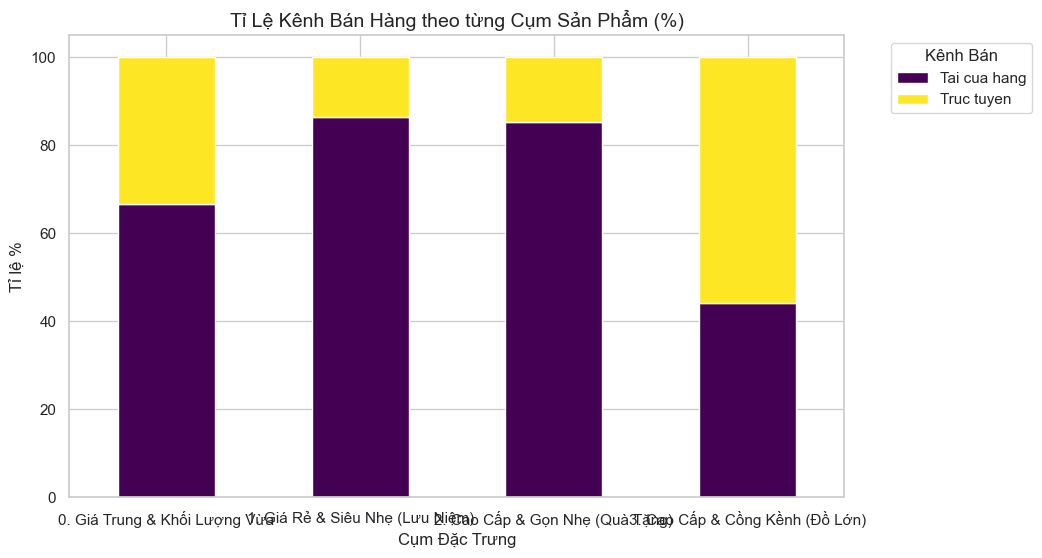

In [ ]:
cross_kenh = pd.crosstab(df['CLUSTER_NAME'], df['KENHBANHANG'], normalize='index') * 100

cross_kenh.plot(kind='bar', stacked=True, colormap='viridis', figsize=(10, 6))
plt.title('Tỉ Lệ Kênh Bán Hàng theo từng Cụm Sản Phẩm (%)', fontsize=14)
plt.ylabel('Tỉ lệ %')
plt.xlabel('Cụm Đặc Trưng')
plt.legend(title='Kênh Bán', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.xticks(rotation=15)
plt.show()

## BƯỚC 4: Vᯁ BIỂU ĐỒ BARCHART CHO THỜI GIAN CUỐI TUẦN

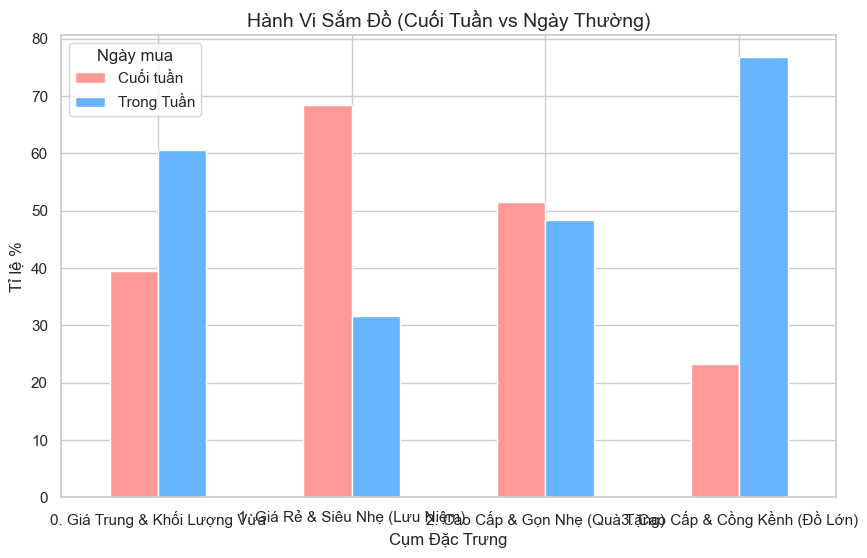

In [11]:
df['IS_WEEKEND'] = df['THUTRONGTUAN'].isin(['Saturday', 'Sunday']).map({True: 'Cuối tuần', False: 'Trong Tuần'})
cross_week = pd.crosstab(df['CLUSTER_NAME'], df['IS_WEEKEND'], normalize='index') * 100

cross_week.plot(kind='bar', figsize=(10, 6), color=['#ff9999','#66b3ff'])
plt.title('Hành Vi Sắm Đồ (Cuối Tuần vs Ngày Thường)', fontsize=14)
plt.ylabel('Tỉ lệ %')
plt.xlabel('Cụm Đặc Trưng')
plt.legend(title='Ngày mua')
plt.xticks(rotation=0)
plt.show()